How Do Surface Termperatures And NDVI Levels Impact The New York City Subway?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import leafmap.leafmap as leafmap
from ipyleaflet import WidgetControl, basemaps
import ipywidgets as widgets
import rioxarray

The New York City subway is one of the most vital parts of the city. It connects people living in the city to services and oppurtunities. It can provide people access to jobs, housing, education, and cultural events. It is also 3 dollars for a single fare which makes it the cheapest and most accessible system for people in the city to get around. The performance of the subways is directly impacted by several factors, including old technology on most tracks, ridership levels, as well as the physical environment. The city has a lot of parks, trees, and plants which help mitigate environmental issues. New York deals with the Urban Heat Island Effect, where city structures like buildings, sidewalks, and roads absorb a lot of heat. Rain can also impact the city a lot. The city has a system to catch stormwater, but it is capped at one and a half inches. If more rain the system can't handle is put in, it can cause severe flooding. This happened during July 2025, when a downpour led to a flash flood alert for all 5 borouhghs, and caused water to flood into subway stops.

The other most important part of the environment that impacts subways is heat severity. The physical structure of stations are different, but all of them are made of materials including metal, concrete, and asphalt. These are all materials which absorb a lot of heat. Some stations can get as hot as 98 degrees, which can be very dangerous if a train is delayed. Heat is one of the main priorities in the MTA 2025 - 2029 Capital Plan. It is important because it directly impacts the safety of passengers. If a subway is delayed for a long time in the summer, and someone is standing for a long time on an elevated track absorbing heat, it can lead to dehydration, heat cramps, and other issues.

One of the most important parts of the city that can mitigate these issues is green space. Large parks like Van Cortlandt Park, Prospect Park, and Central Park have large amounts of vegetation which absorb both heat and rain. These can absorb a lot more rain than the city's stormwater system and not overflow. In this project, I analyzed the relationship between heat levels, and NDVI. The Rockaway Shuttle is an interesting part of the system because it runs on a part of the city that is surrounded by the Atlantic Ocean. The areas is prone to flooding due to it's proximity to the water. 

The subway system is made of 28 lines that are in each borough. The structures of each stop are different, because the system was built by separate companies in the 20th Century which were eventually combined to create the modern MTA. Because different companies built the system, there are various station types. These include Subway, Open Cut, Elevated, Enbanked, and Viaduct. The Subway type is the underground type, and most lines in Manhattan run underground. Elevated stops are ones that are located above ground, and are more common in outer boroughs. Enbanked and Open Cut Stations are both outdoors also but on ground level. Viaducts are elevated stops that are built with large structures made of concrete, brick or steel. Steel and concrete are both substances that absorb a lot of heat. 

In [3]:
image_folder = "/Users/joshdunford/geocomputation final/bronxLC09/"
b4_path = os.path.join(image_folder, "LC08_L2SP_013032_20250915_20250920_02_T1_SR_B4.TIF")
b5_path = os.path.join(image_folder, "LC08_L2SP_013032_20250915_20250920_02_T1_SR_B5.TIF")
heat_path = os.path.join(image_folder, "LC08_L2SP_013032_20250915_20250920_02_T1_ST_B10.TIF")

borough_boundary_path = "/Users/joshdunford/geocomputation final/Borough Boundaries_20260508"
subway_stops_path = "/Users/joshdunford/geocomputation final/MTA_Subway_Stations_20260410.geojson" 

temp_tiff_out = "nyc_all_temp_fahrenheit.tif"
ndvi_tiff_out = "nyc_all_ndvi.tif"


The first step I took was downloading Landsat 08 Satellite Images from USGS Earth Explorer. I set the date range to include all of 2025 and got data from September 2025. I also downloaded shapefiles for borough boundaries and subway stops from NYC Open Data. 

In [4]:

boroughs = gpd.read_file(borough_boundary_path)
nyc_geom = boroughs[boroughs['boroname'].str.lower().isin(['bronx', 'manhattan', 'brooklyn', 'queens', 'staten island'])]

subway_stops = gpd.read_file(subway_stops_path)
subway_stops = subway_stops.to_crs(nyc_geom.crs) 
nyc_subway_stops = gpd.clip(subway_stops, nyc_geom)

columnstodrop = [
    ':id', ':version', ':created_at', ':updated_at', 'gtfs_stop_id',
    'station_id', 'complex_id', 'cbd', 'gtfs_latitude', 'gtfs_longitude',
    'north_direction_label', 'south_direction_label', 'ada',
    'ada_northbound', 'ada_southbound', 'ada_notes',
    ':@computed_region_yamh_8v7k', ':@computed_region_wbg7_3whc',
    ':@computed_region_kjdx_g34t'
]
updated_subway_stops = nyc_subway_stops.drop(columns=columnstodrop, errors='ignore')


with rasterio.open(heat_path) as src_heat:
    nyc_geom_heat = nyc_geom.to_crs(src_heat.crs)
    heat_clipped, heat_transform = mask(src_heat, nyc_geom_heat.geometry.values, crop=True)
    heat_array = heat_clipped[0].astype(float)
    
    nodata_heat = src_heat.nodata if src_heat.nodata is not None else 0
    heat_array[heat_array == nodata_heat] = np.nan
    meta_heat = src_heat.meta.copy()

kelvin_array = (heat_array * 0.00341802) + 149.0
fahrenheit_array = (kelvin_array - 273.15) * 9/5 + 32

meta_heat.update({
    "driver": "GTiff", "height": fahrenheit_array.shape[0], "width": fahrenheit_array.shape[1],
    "transform": heat_transform, "dtype": 'float64', "count": 1, "nodata": np.nan
})
with rasterio.open(temp_tiff_out, "w", **meta_heat) as dst:
    dst.write(fahrenheit_array, 1)


with rasterio.open(b4_path) as src_b4:
    nyc_geom_b4 = nyc_geom.to_crs(src_b4.crs)
    b4_clipped, b4_transform = mask(src_b4, nyc_geom_b4.geometry.values, crop=True)
    b4_array = b4_clipped[0].astype(float)
    meta_ndvi = src_b4.meta.copy()

with rasterio.open(b5_path) as src_b5:
    nyc_geom_b5 = nyc_geom.to_crs(src_b5.crs)
    b5_clipped, _ = mask(src_b5, nyc_geom_b5.geometry.values, crop=True)
    b5_array = b5_clipped[0].astype(float)

np.seterr(divide='ignore', invalid='ignore')
ndvi_array = (b5_array - b4_array) / (b5_array + b4_array)
ndvi_array[b5_array == 0] = np.nan
ndvi_array[b4_array == 0] = np.nan

meta_ndvi.update({
    "driver": "GTiff", "height": ndvi_array.shape[0], "width": ndvi_array.shape[1],
    "transform": b4_transform, "dtype": 'float64', "count": 1, "nodata": np.nan
})
with rasterio.open(ndvi_tiff_out, "w", **meta_ndvi) as dst:
    dst.write(ndvi_array, 1)


subway_wgs84 = updated_subway_stops.to_crs("EPSG:4326")
station_column = "stop_name" 

subway_meters = updated_subway_stops.to_crs("EPSG:2263")
subway_meters['geometry'] = subway_meters.geometry.buffer(165) 

temp_list = []
ndvi_list = []

with rasterio.open(temp_tiff_out) as r_temp, rasterio.open(ndvi_tiff_out) as r_ndvi:
    buffers_temp_crs = subway_meters.to_crs(r_temp.crs)
    buffers_ndvi_crs = subway_meters.to_crs(r_ndvi.crs)
    
    for i in range(len(subway_meters)):
        try:
            geom = [buffers_temp_crs.geometry.iloc[i]]
            out_img, _ = mask(r_temp, geom, crop=True)
            val = np.nanmean(out_img)
            temp_list.append(round(val, 1) if not np.isnan(val) else "No Data")
        except:
            temp_list.append("No Data")
            
        try:
            geom = [buffers_ndvi_crs.geometry.iloc[i]]
            out_img, _ = mask(r_ndvi, geom, crop=True)
            val = np.nanmean(out_img)
            ndvi_list.append(round(val, 3) if not np.isnan(val) else "No Data")
        except:
            ndvi_list.append("No Data")

subway_wgs84['Temperature_F'] = temp_list
subway_wgs84['NDVI_Score'] = ndvi_list


clean_subway = subway_wgs84.drop(columns='geometry', errors='ignore').copy()
clean_subway = clean_subway[(clean_subway['Temperature_F'] != "No Data") & (clean_subway['NDVI_Score'] != "No Data")]
clean_subway['Temperature_F'] = pd.to_numeric(clean_subway['Temperature_F'])
clean_subway['NDVI_Score'] = pd.to_numeric(clean_subway['NDVI_Score'])


detected_col = 'borough' if 'borough' in clean_subway.columns else 'boroname'
clean_subway['boro_clean'] = clean_subway[detected_col].astype(str).str.lower()



To clean the data and only add the most important rows, I used pandas to drop columsn I didn't need. I wanted to show daytime route, stop name and structure, borough, temperature, and NDVI. I calculated NDVI using the formula Band 5 - Band 4 / Band 5 + Band 4. I also calculated Land Surface Temperature using Band 10. I also clipped raster photos to Borough Boundaries using geopandas.

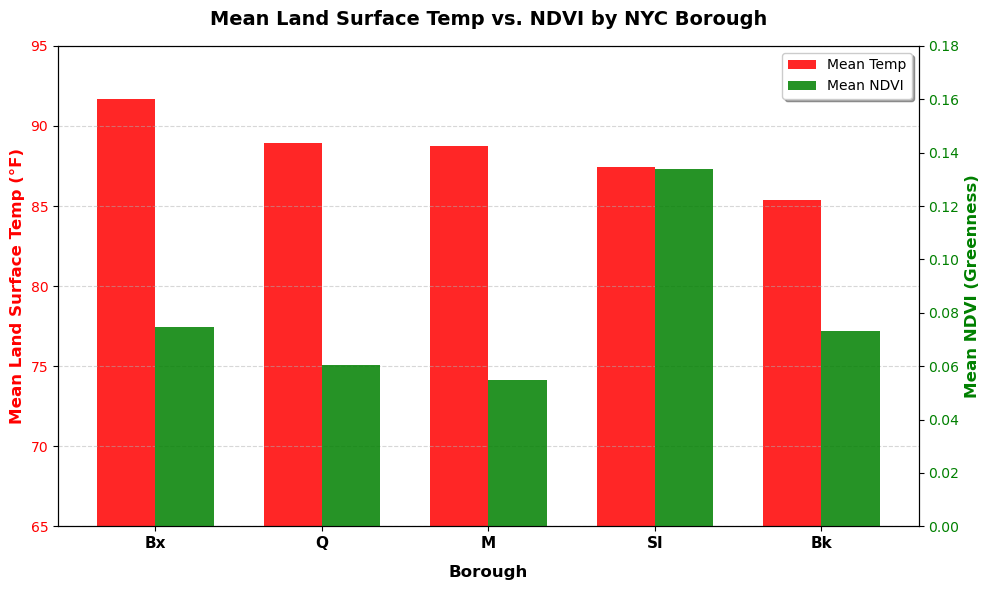

In [5]:
df_means = subway_wgs84.groupby('borough')[['Temperature_F', 'NDVI_Score']].mean().reset_index()
df_means = df_means.sort_values(by='Temperature_F', ascending=False)

boroughs = df_means['borough'].tolist()
lst_means = df_means['Temperature_F'].tolist()
ndvi_means = df_means['NDVI_Score'].tolist()


x = np.arange(len(boroughs))  
bar_width = 0.35              


fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

color_lst = 'Red'  

bar1 = ax1.bar(x - bar_width/2, lst_means, bar_width, color=color_lst, alpha=0.85, label='Mean Temp')


ax1.set_title('Mean Land Surface Temp vs. NDVI by NYC Borough', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Mean Land Surface Temp (°F)', color=color_lst, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_lst)
ax1.set_ylim(65, 95)  


ax2 = ax1.twinx()
color_ndvi = 'Green'  

bar2 = ax2.bar(x + bar_width/2, ndvi_means, bar_width, color=color_ndvi, alpha=0.85, label='Mean NDVI')


ax2.set_ylabel('Mean NDVI (Greenness)', color=color_ndvi, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_ndvi)
ax2.set_ylim(0, 0.18)  

# 5. Fix X-axis labels on the bottom
ax1.set_xlabel('Borough', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(boroughs, fontsize=11, fontweight='bold')

# Combine legends from both axes seamlessly into one box
bars = [bar1, bar2]
labels = [b.get_label() for b in bars]
ax1.legend(bars, labels, loc='upper right', frameon=True, facecolor='white', shadow=True)

plt.tight_layout()
plt.savefig('borough_side_by_side_bars.png', dpi=300, bbox_inches='tight')
plt.show()


This table shows the relationship between NDVI and Land Surface Temperature in each borough. The biggest difference in NDVI and heat severity is in the Bronx. The Bronx has a lot of green space but most of it is located in the Northern Bronx. Van Cortlandt Park, Pelham Bay Park, and Bronx Park all have very high NDVI levels throughout the year. The South Bronx is one of the least green areas in all of the city and has a lot of freeways. This leads to high heat severity in the stations that serve the South Bronx. The lowest difference is in Staten Island, which is because the borough is filled with a lot more green space, due to being more suburban and not having as many physical features that absorb a lot of heat. One issue with most tracks are that they are made of metal and concrete, which are both materials that absorb a lot of heat. Outdoor stops like Pelham Bay Park and Prospect Park both have a lot of green space, but the actual tracks are made of material that absorbs direct heat from the sun.

In [8]:

boroughboundaries = gpd.read_file('/Users/joshdunford/geocomputation final/Borough Boundaries_20260508/boroughboundary.shp')


if boroughboundaries.crs != "EPSG:4326":
    boroughboundaries = boroughboundaries.to_crs("EPSG:4326")


borough_shapefile_col = 'boroname'


borough_configs = {
    "Manhattan": {
        "code": "M", "shape_name": "Manhattan",
        "center": [40.7750, -73.9700], "zoom": 12,
        "bounds": [[40.6900, -74.0200], [40.8800, -73.9000]]
    },
    "Brooklyn": {
        "code": "Bk", "shape_name": "Brooklyn",
        "center": [40.6450, -73.9450], "zoom": 12,
        "bounds": [[40.5600, -74.0400], [40.7400, -73.8400]]
    },
    "Queens": {
        "code": "Q", "shape_name": "Queens",
        "center": [40.7100, -73.8200], "zoom": 11,
        "bounds": [[40.5500, -73.9700], [40.8100, -73.6900]]
    },
    "The Bronx": {
        "code": "Bx", "shape_name": "Bronx", 
        "center": [40.8500, -73.8700], "zoom": 12,
        "bounds": [[40.7800, -73.9300], [40.9200, -73.7700]]
    },
    "Staten Island": {
        "code": "SI", "shape_name": "Staten Island",
        "center": [40.5800, -74.1500], "zoom": 12,
        "bounds": [[40.4900, -74.2500], [40.6600, -74.0500]]
    }
}


def preclip_borough_rasters():
    needed_files = []
    for cfg in borough_configs.values():
        needed_files.extend([f"temp_clip_{cfg['code']}_lst.tif", f"temp_clip_{cfg['code']}_ndvi.tif"])
        
    all_exist = all(os.path.exists(f) for f in needed_files)
    if all_exist:
        return 
        
    rds_temp = rioxarray.open_rasterio(temp_tiff_out)
    rds_ndvi = rioxarray.open_rasterio(ndvi_tiff_out)
    
    for name, config in borough_configs.items():
        boro_poly = boroughboundaries[boroughboundaries[borough_shapefile_col] == config["shape_name"]].geometry
        if boro_poly.empty:
            continue
            
        clipped_temp = rds_temp.rio.clip(boro_poly.values, boroughboundaries.crs, drop=True)
        clipped_ndvi = rds_ndvi.rio.clip(boro_poly.values, boroughboundaries.crs, drop=True)
        
        clipped_temp.rio.to_raster(f"temp_clip_{config['code']}_lst.tif")
        clipped_ndvi.rio.to_raster(f"temp_clip_{config['code']}_ndvi.tif")


preclip_borough_rasters()


dashboard_rows = []

def create_blank_map(config):
    m = leafmap.Map(
        center=config["center"],     
        zoom=config["zoom"],                        
        backend="ipyleaflet",
        basemap=basemaps.CartoDB.PositronNoLabels,  
        max_bounds=config["bounds"],   
        zoom_control=False,                 
        scroll_wheel_zoom=False,       
        dragging=False,                 
        touch_zoom=False,               
        box_zoom=False,                 
        double_click_zoom=False         
    )
    m.clear_controls()
    m.layout.height = '420px'          
    m.layout.width = '100%'
    return m

def bind_hover_events(map_obj, filtered_gdf, title_text):
    info_box = widgets.HTML(
        value=f'<div style="background: white; padding: 6px 10px; border-radius: 4px; border: 1px solid gray; font-size:12px;"><b>{title_text}</b><br>Hover over a station</div>'
    )
    control = WidgetControl(widget=info_box, position="bottomright")
    map_obj.add_control(control)
    
    def update_box(feature, **kwargs):
        props = feature['properties']
        st_name = props.get(station_column, "Unknown Station")
        temp = props.get('Temperature_F', "No Data")
        ndvi = props.get('NDVI_Score', "No Data")
        
        
        routes = props.get('daytime_routes', "No Data")
        struct = props.get('structure', "No Data")
        
       
        info_box.value = f"""
        <div style="background: white; padding: 6px 10px; border-radius: 4px; border: 1px solid gray; font-size:12px; line-height: 1.4; min-width: 180px;">
            <b>Station:</b> {st_name}<br>
            <b>Routes:</b> {routes} | <b>Type:</b> {struct}<br>
            <b>Temp:</b> {temp}°F | <b>NDVI:</b> {ndvi}
        </div>"""
        
    def reset_box(feature, **kwargs):
        info_box.value = f'<div style="background: white; padding: 6px 10px; border-radius: 4px; border: 1px solid gray; font-size:12px;"><b>{title_text}</b><br>Hover over a station</div>'

    my_point_style = {"radius": 4, "color": "black", "fillColor": "white", "fillOpacity": 0.8, "weight": 1}
    my_hover_style = {"fillColor": "yellow", "fillOpacity": 1.0}
    
    map_obj.add_gdf(
        filtered_gdf, layer_name="Subway Stations", zoom_to_layer=False,
        point_style=my_point_style, hover_style=my_hover_style,
        hover_popup=False, popup=None,
        info_mode=None # Suppresses built-in fallback info tables from popping up
    )
    
    subway_layer = map_obj.find_layer("Subway Stations")
    subway_layer.on_hover(update_box)
    subway_layer.on_mouseout(reset_box)


for name, config in borough_configs.items():
    temp_clip_path = f"temp_clip_{config['code']}_lst.tif"
    ndvi_clip_path = f"temp_clip_{config['code']}_ndvi.tif"
    
    
    if not os.path.exists(temp_clip_path) or not os.path.exists(ndvi_clip_path):
        continue
        
    row_title = widgets.HTML(
        value=f'<div style="font-family: sans-serif; font-size: 18px; font-weight: bold; color: #2c3e50; margin-top: 25px; padding-bottom: 5px; border-bottom: 2px solid #bdc3c7;">{name} Analysis</div>'
    )
    
    
    borough_gdf = subway_wgs84[subway_wgs84['borough'] == config["code"]]
    
   
    map_left = create_blank_map(config)
    map_left.add_raster(temp_clip_path, cmap='inferno', vmin=75, vmax=100, nodata=np.nan, opacity=1.0)
    bind_hover_events(map_left, borough_gdf, "Land Surface Temp")
    
    
    map_right = create_blank_map(config)
    map_right.add_raster(ndvi_clip_path, cmap='YlGn', vmin=0.0, vmax=0.6, nodata=np.nan, opacity=1.0)
    bind_hover_events(map_right, borough_gdf, "Vegetation Index (NDVI)")
    
    
    map_pair_row = widgets.HBox([map_left, map_right], layout=widgets.Layout(gap='15px'))
    
    complete_borough_row = widgets.VBox([row_title, map_pair_row])
    dashboard_rows.append(complete_borough_row)


full_dashboard = widgets.VBox(dashboard_rows)
full_dashboard



These maps show the NDVI and temperature for each subway stop. 

In [7]:
import ipywidgets as widgets

# 1. HTML String for Heat Severity Table (Hottest vs Coolest)
heat_table_html = """
<div style="font-family: sans-serif; margin-right: 20px;">
    <h3 style="color: #c0392b; border-bottom: 2px solid #e74c3c; padding-bottom: 5px; margin-bottom: 10px;">
        Stations with Highest vs Lowest Heat Severity
    </h3>
    <table style="width: 100%; border-collapse: collapse; font-size: 13px; margin-bottom: 15px;">
        <tr style="background-color: #fadbd8; font-weight: bold; border-bottom: 2px solid #e74c3c;">
            <th style="padding: 6px; text-align: left;">Top 5 Hottest Stations</th>
            <th style="padding: 6px; text-align: center;">Boro</th>
            <th style="padding: 6px; text-align: right;">Temp (°F)</th>
        </tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Beach 25 St</td><td style="text-align: center;">Q</td><td style="text-align: right; font-weight: bold; color: #c0392b;">98.2</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Mets-Willets Point</td><td style="text-align: center;">Q</td><td style="text-align: right; font-weight: bold; color: #c0392b;">98.2</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Kingsbridge Rd</td><td style="text-align: center;">Bx</td><td style="text-align: right; font-weight: bold; color: #c0392b;">98.2</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">145 St</td><td style="text-align: center;">M</td><td style="text-align: right;">97.7</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">181 St</td><td style="text-align: center;">M</td><td style="text-align: right;">97.5</td></tr>
    </table>
    
    <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
        <tr style="background-color: #d6eaf8; font-weight: bold; border-bottom: 2px solid #3498db;">
            <th style="padding: 6px; text-align: left;">Top 5 Coolest Stations</th>
            <th style="padding: 6px; text-align: center;">Boro</th>
            <th style="padding: 6px; text-align: right;">Temp (°F)</th>
        </tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Beach 90 St</td><td style="text-align: center;">Q</td><td style="text-align: right; font-weight: bold; color: #2980b9;">42.0</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Beach 98 St</td><td style="text-align: center;">Q</td><td style="text-align: right; font-weight: bold; color: #2980b9;">45.1</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">New Lots Av</td><td style="text-align: center;">Bk</td><td style="text-align: right; font-weight: bold; color: #2980b9;">48.8</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Beach 67 St</td><td style="text-align: center;">Q</td><td style="text-align: right;">50.5</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">East 105 St</td><td style="text-align: center;">Bk</td><td style="text-align: right;">52.3</td></tr>
    </table>
</div>
"""

# 2. HTML String for NDVI Table (Greenest vs Least Green)
ndvi_table_html = """
<div style="font-family: sans-serif;">
    <h3 style="color: #1e8449; border-bottom: 2px solid #27ae60; padding-bottom: 5px; margin-bottom: 10px;">
         Highest vs Lowest NDVI Scores
    </h3>
    <table style="width: 100%; border-collapse: collapse; font-size: 13px; margin-bottom: 15px;">
        <tr style="background-color: #d4efdf; font-weight: bold; border-bottom: 2px solid #27ae60;">
            <th style="padding: 6px; text-align: left;">Top 5 Greenest Stations</th>
            <th style="padding: 6px; text-align: center;">Boro</th>
            <th style="padding: 6px; text-align: right;">NDVI</th>
        </tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Avenue M</td><td style="text-align: center;">Bk</td><td style="text-align: right; font-weight: bold; color: #1e8449;">0.353</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">High St</td><td style="text-align: center;">Bk</td><td style="text-align: right; font-weight: bold; color: #1e8449;">0.312</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Pleasant Plains</td><td style="text-align: center;">SI</td><td style="text-align: right; font-weight: bold; color: #1e8449;">0.283</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Richmond Valley</td><td style="text-align: center;">SI</td><td style="text-align: right;">0.281</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Wilson Av</td><td style="text-align: center;">Bk</td><td style="text-align: right;">0.272</td></tr>
    </table>
    
    <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
        <tr style="background-color: #fcf3cf; font-weight: bold; border-bottom: 2px solid #f1c40f;">
            <th style="padding: 6px; text-align: left;">Top 5 Least Green Stations</th>
            <th style="padding: 6px; text-align: center;">Boro</th>
            <th style="padding: 6px; text-align: right;">NDVI</th>
        </tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Beach 67 St</td><td style="text-align: center;">Q</td><td style="text-align: right; font-weight: bold; color: #b7950b;">0.002</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">42 St-Port Authority</td><td style="text-align: center;">M</td><td style="text-align: right; font-weight: bold; color: #b7950b;">0.002</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Beach 90 St</td><td style="text-align: center;">Q</td><td style="text-align: right; font-weight: bold; color: #b7950b;">0.002</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Wall St</td><td style="text-align: center;">M</td><td style="text-align: right;">0.003</td></tr>
        <tr><td style="padding: 5px; border-bottom: 1px solid #ddd;">Times Sq-42 St</td><td style="text-align: center;">M</td><td style="text-align: right;">0.004</td></tr>
    </table>
</div>
"""

# 3. Render side-by-side using an HBox container
widget_left = widgets.HTML(value=heat_table_html, layout=widgets.Layout(width='50%'))
widget_right = widgets.HTML(value=ndvi_table_html, layout=widgets.Layout(width='50%'))

indicators_dashboard = widgets.HBox([widget_left, widget_right], layout=widgets.Layout(gap='20px', margin='20px 0px'))
indicators_dashboard


This table shows the stops with the highest and lowest levels of both NDVI and temperature. The hottest 3 stations are located close to structures that absorb a lot of heat. The Beach 25th Street station is on the A train and is located above the Rockaway Freeway, which is a major road in the area. Mets Willets Point is locoted by Citi Field, which is a stadium with a large parking lot. Kingsbridge Road is located above a busy section on Jerome Avenue. The lowest 3 are all along the Rockaway Shuttle. The reason they are way lower is because the Atlantic Ocean is a very large natural heat sink and so it absorbs all direct heat. 

Avenue M is a high NDVI stop because it is located in an open cut track near houses with backyards or gardens. High Street is located near a tree lined part of Brooklyn, as well as Cadman Plaza Park. A lot of the Staten Island stops had high NDVI levels, since it has less heat absorbing material than other boroughs. The three lowest NDVI scores were due to land type around each stop. The Beach 67 Street and Beach 90 Street are both located by the ocean. Water absorbs near-infrared (NIR) light instead of reflecting it. Because of this, deep water bodies usually yield negative or near-zero NDVI values during remote sensing analysis. Port Authority Bus Terminal is a few blocks from Times Square, which is an area with very little green space due to being full of buildings, sidewalks, streets, and little green space.

The MTA Capital Plan is currently 68.4 billion dollars. This money is being used for improvements to the system including modern signalling, track repair, and service expansion. The current Capital Plan has a section on climate. They have plans to address both heat and rain. They are planning on building flood and heat protection infrastructure at the 20 most vulnerable stations, which can include green space to act as natural sponges. Some ways the MTA has mitigated the heat issue is by installing covers over elevated platforms to give people shade, as well as using new geothermal technology on the Q train Second Avenue stations. 

Sources 

USGS Earth Explorer (Landsat08 Images)
NYC Open Data (Borough Boundaries)
MTA Open Data (Subway Stops)
2025 - 2029 Capital Plan (MTA)

